In [2]:
# F-02 — Dataset environment check

import os
import pandas as pd

DATA_ROOT = "/content/sen1floods11"
SPLIT_DIR = os.path.join(DATA_ROOT, "splits")

print("DATA_ROOT exists :", os.path.exists(DATA_ROOT))
print("SPLIT_DIR exists :", os.path.exists(SPLIT_DIR))

if os.path.exists(SPLIT_DIR):
    print("\nFiles in splits folder:")
    print(os.listdir(SPLIT_DIR))

DATA_ROOT exists : False
SPLIT_DIR exists : False


In [3]:
# ============================================================
# F-02 — Flood Baseline
# Cell 1: Environment setup
# ============================================================

import os
import sys
import subprocess

# Install rasterio if necessary
try:
    import rasterio
except ImportError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "rasterio"
    ])

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    confusion_matrix
)

print("Environment ready.")
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Rasterio:", rasterio.__version__)

Environment ready.
Python: 3.13.16
NumPy: 2.1.3
Pandas: 2.2.3
Rasterio: 1.5.2


In [4]:
# ============================================================
# F-02 — Cell 2: Create project working directories
# ============================================================

DATA_ROOT = "/content/sen1floods11"

SPLIT_DIR = os.path.join(DATA_ROOT, "splits")
DATA_DIR = os.path.join(DATA_ROOT, "data")
RESULTS_DIR = os.path.join(DATA_ROOT, "f02_results")

os.makedirs(SPLIT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Directories created:")
print("DATA_ROOT  :", DATA_ROOT)
print("SPLIT_DIR  :", SPLIT_DIR)
print("DATA_DIR   :", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

Directories created:
DATA_ROOT  : /content/sen1floods11
SPLIT_DIR  : /content/sen1floods11/splits
DATA_DIR   : /content/sen1floods11/data
RESULTS_DIR: /content/sen1floods11/f02_results


In [5]:
# ============================================================
# F-02 — Cell 3: Verify official Sen1Floods11 bucket
# ============================================================

import subprocess

BUCKET = "gs://sen1floods11/v1.1"

result = subprocess.run(
    ["gsutil", "ls", BUCKET + "/"],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print("ERROR:")
    print(result.stderr)
    raise RuntimeError("Could not access the Sen1Floods11 bucket.")

print("Official Sen1Floods11 bucket access: OK")

gs://sen1floods11/v1.1/Sen1Floods11_Metadata.geojson
gs://sen1floods11/v1.1/catalog.zip
gs://sen1floods11/v1.1/catalog/
gs://sen1floods11/v1.1/checkpoints/
gs://sen1floods11/v1.1/data/
gs://sen1floods11/v1.1/splits/

Official Sen1Floods11 bucket access: OK


In [6]:
# ============================================================
# F-02 — Cell 4: Download official split reference files
# ============================================================

split_files = [
    "flood_train_data.csv",
    "flood_valid_data.csv",
    "flood_test_data.csv",
    "flood_bolivia_data.csv"
]

for filename in split_files:

    remote = f"{BUCKET}/splits/flood_handlabeled/{filename}"
    local = os.path.join(SPLIT_DIR, filename)

    print(f"Downloading: {filename}")

    result = subprocess.run(
        ["gsutil", "-q", "cp", remote, local],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Failed to download {filename}")

print("\nAll split files downloaded successfully.")

Downloading: flood_train_data.csv
Downloading: flood_valid_data.csv
Downloading: flood_test_data.csv
Downloading: flood_bolivia_data.csv

All split files downloaded successfully.


In [7]:
# ============================================================
# F-02 — Cell 5: Load split reference tables
# ============================================================

train_df = pd.read_csv(
    os.path.join(SPLIT_DIR, "flood_train_data.csv")
)

valid_df = pd.read_csv(
    os.path.join(SPLIT_DIR, "flood_valid_data.csv")
)

test_df = pd.read_csv(
    os.path.join(SPLIT_DIR, "flood_test_data.csv")
)

bolivia_df = pd.read_csv(
    os.path.join(SPLIT_DIR, "flood_bolivia_data.csv")
)

print("Sen1Floods11 split sizes")
print("-" * 40)

print("Training   :", len(train_df))
print("Validation :", len(valid_df))
print("Test       :", len(test_df))
print("Bolivia    :", len(bolivia_df))

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nFirst training row:")
print(train_df.iloc[0].to_dict())

Sen1Floods11 split sizes
----------------------------------------
Training   : 251
Validation : 88
Test       : 89
Bolivia    : 14

Training columns:
['Ghana_103272_S1Hand.tif', 'Ghana_103272_LabelHand.tif']

First training row:
{'Ghana_103272_S1Hand.tif': 'Ghana_24858_S1Hand.tif', 'Ghana_103272_LabelHand.tif': 'Ghana_24858_LabelHand.tif'}


In [8]:
# ============================================================
# F-02 — Cell 6: Parse image/label pairs
# ============================================================

def parse_pairs(df):
    """
    Convert Sen1Floods11's two-column filename structure
    into explicit Sentinel-1 / label pairs.
    """

    pairs = []

    for _, row in df.iterrows():

        filenames = [
            str(value)
            for value in row.tolist()
            if pd.notna(value)
        ]

        if len(filenames) != 2:
            raise ValueError(
                f"Expected exactly 2 filenames, got: {filenames}"
            )

        s1_files = [
            f for f in filenames
            if "_S1Hand.tif" in f
        ]

        label_files = [
            f for f in filenames
            if "_LabelHand.tif" in f
        ]

        if len(s1_files) != 1 or len(label_files) != 1:
            raise ValueError(
                f"Could not identify S1/label pair: {filenames}"
            )

        pairs.append({
            "s1_file": s1_files[0],
            "label_file": label_files[0]
        })

    return pd.DataFrame(pairs)


train_pairs = parse_pairs(train_df)
valid_pairs = parse_pairs(valid_df)
test_pairs = parse_pairs(test_df)
bolivia_pairs = parse_pairs(bolivia_df)

print("Parsed pairs:")
print("Training   :", len(train_pairs))
print("Validation :", len(valid_pairs))
print("Test       :", len(test_pairs))
print("Bolivia    :", len(bolivia_pairs))

print("\nFirst training pair:")
print(train_pairs.iloc[0].to_dict())

Parsed pairs:
Training   : 251
Validation : 88
Test       : 89
Bolivia    : 14

First training pair:
{'s1_file': 'Ghana_24858_S1Hand.tif', 'label_file': 'Ghana_24858_LabelHand.tif'}


In [14]:
# ============================================================
# F-02 — Cell 7: Download required Sentinel-1 and label TIFFs
# ============================================================

REMOTE_FLOOD_EVENTS = (
    f"{BUCKET}/data/flood_events/HandLabeled"
)

# Collect unique files from train/validation/test
all_pairs = pd.concat(
    [train_pairs, valid_pairs, test_pairs],
    ignore_index=True
)

all_files = sorted(
    set(all_pairs["s1_file"].tolist() +
        all_pairs["label_file"].tolist())
)

print("Unique raster files required:", len(all_files))

downloaded = 0
skipped = 0

for i, filename in enumerate(all_files, start=1):

    local_path = os.path.join(DATA_DIR, filename)

    if os.path.exists(local_path):
        skipped += 1
        continue

    # Sen1Floods11 HandLabeled files are under
    # the corresponding subdirectories in the bucket.
    # Use recursive search to locate the exact file.
    result = subprocess.run(
        [
            "gsutil",
            "ls",
            f"{REMOTE_FLOOD_EVENTS}/**/{filename}"
        ],
        capture_output=True,
        text=True
    )

    remote_matches = [
        line.strip()
        for line in result.stdout.splitlines()
        if line.strip().endswith(filename)
    ]

    if not remote_matches:

        # Fallback: recursive listing
        result = subprocess.run(
            [
                "gsutil",
                "ls",
                "-r",
                f"{REMOTE_FLOOD_EVENTS}/"
            ],
            capture_output=True,
            text=True
        )

        remote_matches = [
            line.strip()
            for line in result.stdout.splitlines()
            if line.strip().endswith(filename)
        ]

    if not remote_matches:
        raise FileNotFoundError(
            f"Could not locate official dataset file: {filename}"
        )

    remote_path = remote_matches[0]

    subprocess.run(
        ["gsutil", "-q", "cp", remote_path, local_path],
        check=True
    )

    downloaded += 1

    if i % 20 == 0 or i == len(all_files):
        print(
            f"Progress: {i}/{len(all_files)} "
            f"| downloaded={downloaded}, skipped={skipped}"
        )

print("\nRaster download complete.")
print("Downloaded:", downloaded)
print("Already present:", skipped)

Unique raster files required: 856
Progress: 800/856 | downloaded=9, skipped=791
Progress: 820/856 | downloaded=29, skipped=791
Progress: 840/856 | downloaded=49, skipped=791
Progress: 856/856 | downloaded=65, skipped=791

Raster download complete.
Downloaded: 65
Already present: 791


In [15]:
# ============================================================
# F-02 — Cell 8: Verify local image/label pairs
# ============================================================

def verify_pairs(pairs):
    missing_s1 = []
    missing_label = []

    for _, row in pairs.iterrows():

        s1_path = os.path.join(DATA_DIR, row["s1_file"])
        label_path = os.path.join(DATA_DIR, row["label_file"])

        if not os.path.exists(s1_path):
            missing_s1.append(row["s1_file"])

        if not os.path.exists(label_path):
            missing_label.append(row["label_file"])

    return missing_s1, missing_label


for name, pairs in [
    ("Training", train_pairs),
    ("Validation", valid_pairs),
    ("Test", test_pairs)
]:

    missing_s1, missing_label = verify_pairs(pairs)

    print(f"\n{name}")
    print("Missing Sentinel-1 files:", len(missing_s1))
    print("Missing label files    :", len(missing_label))

    if missing_s1 or missing_label:
        print("Example missing S1:", missing_s1[:3])
        print("Example missing label:", missing_label[:3])
        raise FileNotFoundError(
            f"{name} contains missing raster files."
        )

print("\nAll train/validation/test pairs are available.")


Training
Missing Sentinel-1 files: 0
Missing label files    : 0

Validation
Missing Sentinel-1 files: 0
Missing label files    : 0

Test
Missing Sentinel-1 files: 0
Missing label files    : 0

All train/validation/test pairs are available.


In [16]:
# ============================================================
# F-02 — Cell 9: Sentinel-1 + label loader
# ============================================================

def load_pair(row):
    """
    Load one Sentinel-1 image and its corresponding flood label.

    Returns:
        s1   : NumPy array with shape (2, H, W)
        label: NumPy array with shape (H, W)
        s1_profile
        label_profile
    """

    s1_path = os.path.join(DATA_DIR, row["s1_file"])
    label_path = os.path.join(DATA_DIR, row["label_file"])

    with rasterio.open(s1_path) as src:
        s1 = src.read().astype(np.float32)
        s1_profile = src.profile.copy()

    with rasterio.open(label_path) as src:
        label = src.read(1).astype(np.int16)
        label_profile = src.profile.copy()

    return s1, label, s1_profile, label_profile


sample_s1, sample_label, s1_profile, label_profile = load_pair(
    train_pairs.iloc[0]
)

print("Sentinel-1 shape:", sample_s1.shape)
print("Label shape     :", sample_label.shape)

print("Sentinel-1 CRS:", s1_profile["crs"])
print("Label CRS     :", label_profile["crs"])

print("Dimensions match:",
      sample_s1.shape[1:] == sample_label.shape)

Sentinel-1 shape: (2, 512, 512)
Label shape     : (512, 512)
Sentinel-1 CRS: EPSG:4326
Label CRS     : EPSG:4326
Dimensions match: True


In [20]:
# ============================================================
# F-02 — Cell 10: Inspect multiple training samples
# ============================================================

sample_indices = [0, 1, 2, 3, 4]

for idx in sample_indices:

    s1, label, _, _ = load_pair(train_pairs.iloc[idx])

    vv = s1[0]
    vh = s1[1]

    flood_pixels = np.sum(label == 1)
    total_pixels = label.size

    print(f"\nSample {idx}")
    print("-" * 40)
    print("S1 shape       :", s1.shape)
    print("VV mean        :", np.nanmean(vv))
    print("VH mean        :", np.nanmean(vh))
    print("Flood pixels   :", flood_pixels)
    print("Flood coverage :", flood_pixels / total_pixels)


Sample 0
----------------------------------------
S1 shape       : (2, 512, 512)
VV mean        : -9.1029
VH mean        : -15.185305
Flood pixels   : 484
Flood coverage : 0.0018463134765625

Sample 1
----------------------------------------
S1 shape       : (2, 512, 512)
VV mean        : -9.221717
VH mean        : -16.074768
Flood pixels   : 3530
Flood coverage : 0.01346588134765625

Sample 2
----------------------------------------
S1 shape       : (2, 512, 512)
VV mean        : -10.145384
VH mean        : -16.53156
Flood pixels   : 2772
Flood coverage : 0.0105743408203125

Sample 3
----------------------------------------
S1 shape       : (2, 512, 512)
VV mean        : -9.333635
VH mean        : -15.181062
Flood pixels   : 0
Flood coverage : 0.0

Sample 4
----------------------------------------
S1 shape       : (2, 512, 512)
VV mean        : -8.567797
VH mean        : -14.560406
Flood pixels   : 0
Flood coverage : 0.0


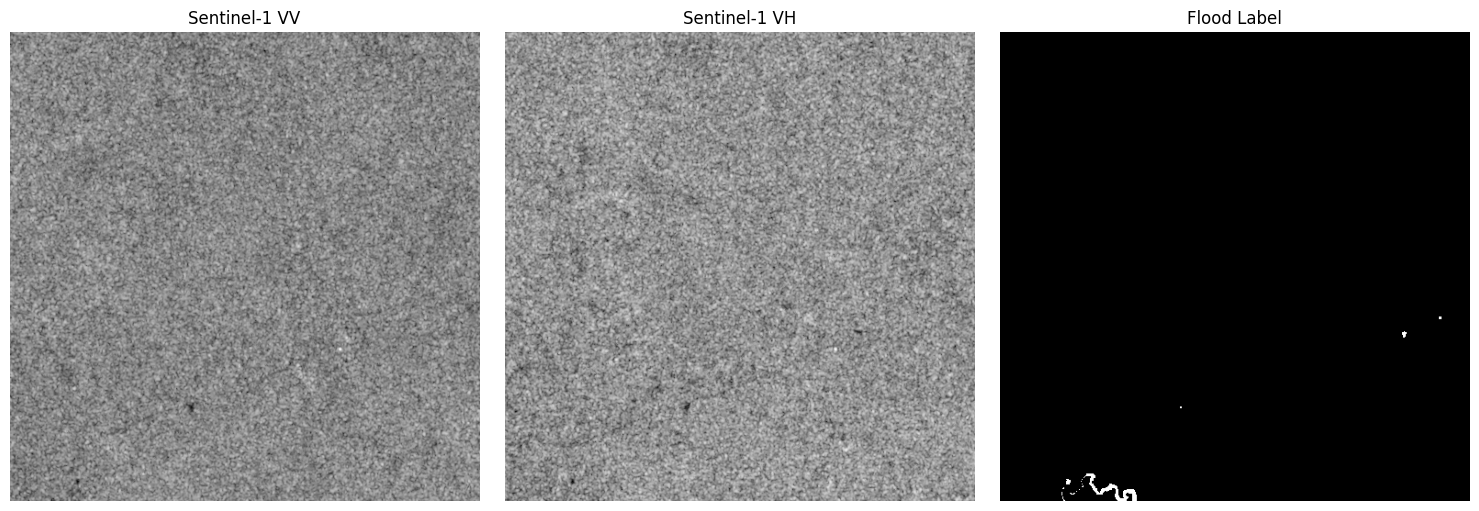

In [17]:
# ============================================================
# F-02 — Cell 11: Visual inspection
# ============================================================

s1, label, _, _ = load_pair(train_pairs.iloc[0])

vv = s1[0]
vh = s1[1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(vv, cmap="gray")
axes[0].set_title("Sentinel-1 VV")
axes[0].axis("off")

axes[1].imshow(vh, cmap="gray")
axes[1].set_title("Sentinel-1 VH")
axes[1].axis("off")

axes[2].imshow(label, cmap="gray")
axes[2].set_title("Flood Label")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# F-02 — Cell 12: Baseline prediction function
# ============================================================

def predict_flood_from_vv(vv, threshold):
    """
    Simple threshold baseline.

    Pixels with VV below the threshold are classified as flood.
    """

    prediction = (vv < threshold).astype(np.uint8)

    return prediction


print("Baseline prediction function created.")

Baseline prediction function created.


In [22]:
# ============================================================
# F-02 — Cell 13: Evaluation metrics
# ============================================================

def calculate_metrics(y_true, y_pred):

    y_true = y_true.astype(np.uint8).ravel()
    y_pred = y_pred.astype(np.uint8).ravel()

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    iou = jaccard_score(
        y_true,
        y_pred,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


print("Metric function ready.")

Metric function ready.


In [28]:
# ============================================================
# F-02 — Cell 13 FIX
# Robust binary flood metrics
# ============================================================

def calculate_metrics(y_true, y_pred):

    # Convert to NumPy arrays
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # --------------------------------------------------------
    # IMPORTANT:
    # Sen1Floods11 flood labels are interpreted as:
    # 0 = non-flood
    # 1 = flood
    #
    # Convert everything explicitly to binary.
    # --------------------------------------------------------

    y_true = (y_true == 1).astype(np.uint8)
    y_pred = (y_pred == 1).astype(np.uint8)

    # Flatten pixel arrays
    y_true = y_true.ravel()
    y_pred = y_pred.ravel()

    # Binary classification metrics
    precision = precision_score(
        y_true,
        y_pred,
        pos_label=1,
        average="binary",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        average="binary",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        pos_label=1,
        average="binary",
        zero_division=0
    )

    iou = jaccard_score(
        y_true,
        y_pred,
        pos_label=1,
        average="binary",
        zero_division=0
    )

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


print("Fixed binary metric function is ready.")

Fixed binary metric function is ready.


In [29]:
# ============================================================
# F-02 — Cell 14 FIX
# Validation threshold search
# ============================================================

thresholds = np.arange(-20.0, 0.1, 1.0)

validation_results = []

for threshold in thresholds:

    all_true = []
    all_pred = []

    for _, row in valid_pairs.iterrows():

        s1, label, _, _ = load_pair(row)

        # Sentinel-1 VV band
        vv = s1[0]

        # Keep only valid numerical pixels
        valid_mask = np.isfinite(vv)

        vv_valid = vv[valid_mask]
        label_valid = label[valid_mask]

        # Convert prediction to binary
        prediction = predict_flood_from_vv(
            vv_valid,
            threshold
        )

        all_true.append(label_valid)
        all_pred.append(prediction)

    # Combine all validation pixels
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    # Calculate metrics
    metrics = calculate_metrics(
        y_true,
        y_pred
    )

    validation_results.append({
        "threshold": threshold,
        **metrics
    })


validation_results_df = pd.DataFrame(
    validation_results
)

print("Validation threshold search completed.")
print()

print(
    validation_results_df[
        ["threshold", "precision", "recall", "f1", "iou"]
    ].to_string(index=False)
)

Validation threshold search completed.

 threshold  precision   recall       f1      iou
     -20.0   0.829054 0.385192 0.525997 0.356850
     -19.0   0.789493 0.438652 0.563961 0.392720
     -18.0   0.737861 0.486451 0.586343 0.414770
     -17.0   0.673898 0.530872 0.593895 0.422369
     -16.0   0.598369 0.574000 0.585931 0.414358
     -15.0   0.514792 0.618042 0.561712 0.390542
     -14.0   0.428529 0.663767 0.520818 0.352098
     -13.0   0.346778 0.711405 0.466270 0.304010
     -12.0   0.275032 0.760403 0.403956 0.253099
     -11.0   0.217078 0.808550 0.342266 0.206466
     -10.0   0.173613 0.853765 0.288550 0.168599
      -9.0   0.143288 0.894452 0.247007 0.140906
      -8.0   0.123487 0.928947 0.217996 0.122332
      -7.0   0.111508 0.956396 0.199729 0.110944
      -6.0   0.104874 0.976038 0.189397 0.104604
      -5.0   0.101475 0.988374 0.184053 0.101354
      -4.0   0.099802 0.994981 0.181408 0.099752
      -3.0   0.098937 0.997943 0.180027 0.098917
      -2.0   0.098447 0.99906

In [30]:
# ============================================================
# F-02 — Cell 15
# Select threshold using validation F1
# ============================================================

best_row = validation_results_df.loc[
    validation_results_df["f1"].idxmax()
]

BEST_THRESHOLD = float(
    best_row["threshold"]
)

print("BEST VALIDATION THRESHOLD")
print("=" * 40)

print("Threshold :", BEST_THRESHOLD)
print("Precision :", best_row["precision"])
print("Recall    :", best_row["recall"])
print("F1-score  :", best_row["f1"])
print("IoU       :", best_row["iou"])

BEST VALIDATION THRESHOLD
Threshold : -17.0
Precision : 0.6738980532093201
Recall    : 0.5308720933880601
F1-score  : 0.5938953106495377
IoU       : 0.42236919850106064


In [31]:
# ============================================================
# F-02 — Cell 16
# Final test evaluation
# ============================================================

all_true = []
all_pred = []

for _, row in test_pairs.iterrows():

    s1, label, _, _ = load_pair(row)

    vv = s1[0]

    valid_mask = np.isfinite(vv)

    vv_valid = vv[valid_mask]
    label_valid = label[valid_mask]

    prediction = predict_flood_from_vv(
        vv_valid,
        BEST_THRESHOLD
    )

    all_true.append(label_valid)
    all_pred.append(prediction)


# Combine all test pixels
y_test_true = np.concatenate(all_true)
y_test_pred = np.concatenate(all_pred)

# Calculate final metrics
test_metrics = calculate_metrics(
    y_test_true,
    y_test_pred
)

print("FINAL TEST RESULTS")
print("=" * 45)

print(f"Threshold : {BEST_THRESHOLD:.2f}")
print(f"Precision : {test_metrics['precision']:.4f}")
print(f"Recall    : {test_metrics['recall']:.4f}")
print(f"F1-score  : {test_metrics['f1']:.4f}")
print(f"IoU       : {test_metrics['iou']:.4f}")

print("\nConfusion counts:")
print("TN:", test_metrics["TN"])
print("FP:", test_metrics["FP"])
print("FN:", test_metrics["FN"])
print("TP:", test_metrics["TP"])

FINAL TEST RESULTS
Threshold : -17.00
Precision : 0.6922
Recall    : 0.5307
F1-score  : 0.6008
IoU       : 0.4294

Confusion counts:
TN: 19679821
FP: 590124
FN: 1173178
TP: 1326897


In [32]:
# ============================================================
# F-02 — Cell 17
# False-alarm and missed-flood analysis
# ============================================================

tn = test_metrics["TN"]
fp = test_metrics["FP"]
fn = test_metrics["FN"]
tp = test_metrics["TP"]

# False-alarm rate:
# Of all actual non-flood pixels, how many were
# incorrectly classified as flood?
false_alarm_rate = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0
)

# Missed-flood rate:
# Of all actual flood pixels, how many were missed?
missed_flood_rate = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0
)

print("ERROR ANALYSIS")
print("=" * 45)

print(f"False-alarm rate  : {false_alarm_rate:.6f}")
print(f"Missed-flood rate : {missed_flood_rate:.6f}")

print("\nRaw counts:")
print("True negatives  :", tn)
print("False positives :", fp)
print("False negatives :", fn)
print("True positives  :", tp)

ERROR ANALYSIS
False-alarm rate  : 0.029113
Missed-flood rate : 0.469257

Raw counts:
True negatives  : 19679821
False positives : 590124
False negatives : 1173178
True positives  : 1326897


In [34]:
# ============================================================
# F-02 — Cell 17: Error analysis
# ============================================================

tn = test_metrics["TN"]
fp = test_metrics["FP"]
fn = test_metrics["FN"]
tp = test_metrics["TP"]

false_alarm_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
missed_flood_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

print("ERROR ANALYSIS")
print("=" * 45)

print(f"False-alarm rate  : {false_alarm_rate:.4f}")
print(f"Missed-flood rate : {missed_flood_rate:.4f}")

print("\nFalse positives:", fp)
print("False negatives:", fn)

ERROR ANALYSIS
False-alarm rate  : 0.0291
Missed-flood rate : 0.4693

False positives: 590124
False negatives: 1173178


VV shape        : (512, 512)
Label shape     : (512, 512)
Prediction shape: (512, 512)


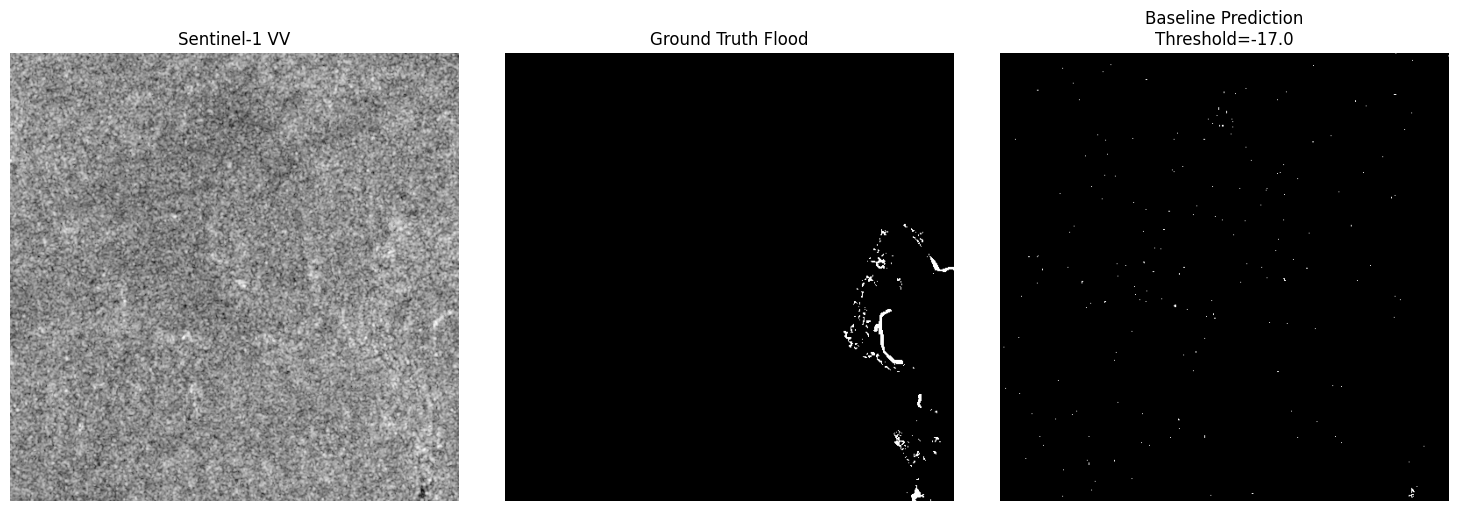

In [43]:
# ============================================================
# F-02 — Visualization FIX
# Recreate prediction with original raster shape
# ============================================================

TEST_VIS_INDEX = 0

row = test_pairs.iloc[TEST_VIS_INDEX]

# Load original 2-D/3-D data
s1, label, _, _ = load_pair(row)

# Sentinel-1 VV
vv = s1[0]

# Create prediction using the COMPLETE 2-D VV image
# This keeps the original 512 x 512 spatial shape.
prediction_2d = predict_flood_from_vv(
    vv,
    BEST_THRESHOLD
)

print("VV shape        :", vv.shape)
print("Label shape     :", label.shape)
print("Prediction shape:", prediction_2d.shape)

# Verify dimensions before plotting
if prediction_2d.shape != label.shape:
    raise ValueError(
        f"Shape mismatch: prediction={prediction_2d.shape}, "
        f"label={label.shape}"
    )

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

axes[0].imshow(
    vv,
    cmap="gray"
)
axes[0].set_title("Sentinel-1 VV")
axes[0].axis("off")

axes[1].imshow(
    label,
    cmap="gray"
)
axes[1].set_title("Ground Truth Flood")
axes[1].axis("off")

axes[2].imshow(
    prediction_2d,
    cmap="gray"
)
axes[2].set_title(
    f"Baseline Prediction\nThreshold={BEST_THRESHOLD:.1f}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

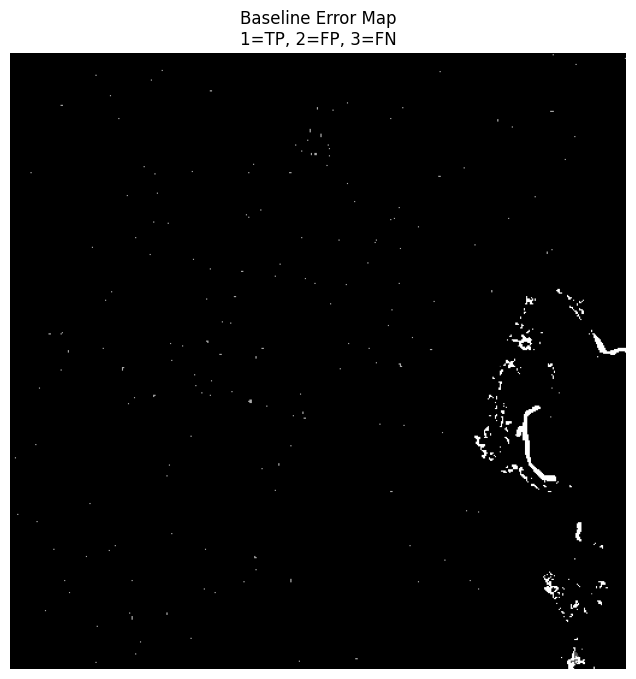

True positives : 27
False positives: 235
False negatives: 1380


In [44]:
# ============================================================
# F-02 — Error Map
# ============================================================

true_mask = (label == 1)
pred_mask = (prediction_2d == 1)

true_positive = true_mask & pred_mask
false_positive = (~true_mask) & pred_mask
false_negative = true_mask & (~pred_mask)

error_map = np.zeros(
    label.shape,
    dtype=np.uint8
)

# 1 = True Positive
# 2 = False Positive
# 3 = False Negative

error_map[true_positive] = 1
error_map[false_positive] = 2
error_map[false_negative] = 3

plt.figure(figsize=(8, 8))

plt.imshow(
    error_map,
    cmap="gray"
)

plt.title(
    "Baseline Error Map\n"
    "1=TP, 2=FP, 3=FN"
)

plt.axis("off")
plt.show()

print("True positives :", np.sum(true_positive))
print("False positives:", np.sum(false_positive))
print("False negatives:", np.sum(false_negative))

In [37]:
# ============================================================
# F-02 — Cell 20: Per-sample test analysis
# ============================================================

per_sample_results = []

for index, row in test_pairs.iterrows():

    s1, label, _, _ = load_pair(row)

    vv = s1[0]

    valid_mask = np.isfinite(vv)

    vv_valid = vv[valid_mask]
    label_valid = label[valid_mask]

    prediction = predict_flood_from_vv(
        vv_valid,
        BEST_THRESHOLD
    )

    metrics = calculate_metrics(
        label_valid,
        prediction
    )

    per_sample_results.append({
        "index": index,
        "s1_file": row["s1_file"],
        "label_file": row["label_file"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "iou": metrics["iou"]
    })


per_sample_df = pd.DataFrame(per_sample_results)

print(per_sample_df.head(10).to_string(index=False))

 index                  s1_file                  label_file  precision   recall       f1      iou
     0 Ghana_1078550_S1Hand.tif Ghana_1078550_LabelHand.tif   0.103053 0.019190 0.032355 0.016443
     1   Ghana_97059_S1Hand.tif   Ghana_97059_LabelHand.tif   0.000000 0.000000 0.000000 0.000000
     2  Ghana_359826_S1Hand.tif  Ghana_359826_LabelHand.tif   0.830998 0.271453 0.409228 0.257251
     3  Ghana_319168_S1Hand.tif  Ghana_319168_LabelHand.tif   0.644223 0.256623 0.367038 0.224768
     4  Ghana_866994_S1Hand.tif  Ghana_866994_LabelHand.tif   0.356136 0.510819 0.419678 0.265565
     5  Ghana_406026_S1Hand.tif  Ghana_406026_LabelHand.tif   0.801684 0.840418 0.820594 0.695769
     6   Ghana_53713_S1Hand.tif   Ghana_53713_LabelHand.tif   0.000000 0.000000 0.000000 0.000000
     7   Ghana_83483_S1Hand.tif   Ghana_83483_LabelHand.tif   0.000000 0.000000 0.000000 0.000000
     8  Ghana_167233_S1Hand.tif  Ghana_167233_LabelHand.tif   0.000000 0.000000 0.000000 0.000000
     9  Ghana_141271

In [38]:
# ============================================================
# F-02 — Cell 21: Identify baseline strengths and failures
# ============================================================

print("BEST 5 TEST SAMPLES BY F1")
print("=" * 60)

print(
    per_sample_df
    .sort_values("f1", ascending=False)
    .head(5)
    .to_string(index=False)
)

print("\nWORST 5 TEST SAMPLES BY F1")
print("=" * 60)

print(
    per_sample_df
    .sort_values("f1", ascending=True)
    .head(5)
    .to_string(index=False)
)

BEST 5 TEST SAMPLES BY F1
 index                     s1_file                     label_file  precision   recall       f1      iou
    42  Paraguay_790830_S1Hand.tif  Paraguay_790830_LabelHand.tif   0.988757 0.924907 0.955767 0.915280
    46 Paraguay_1029191_S1Hand.tif Paraguay_1029191_LabelHand.tif   0.979578 0.908137 0.942506 0.891263
    11     India_591317_S1Hand.tif     India_591317_LabelHand.tif   0.973844 0.908277 0.939918 0.886647
    62    Spain_5650136_S1Hand.tif    Spain_5650136_LabelHand.tif   0.966585 0.854971 0.907359 0.830427
    74 Sri-Lanka_713926_S1Hand.tif Sri-Lanka_713926_LabelHand.tif   0.932676 0.861613 0.895737 0.811163

WORST 5 TEST SAMPLES BY F1
 index                 s1_file                 label_file  precision  recall  f1  iou
     1  Ghana_97059_S1Hand.tif  Ghana_97059_LabelHand.tif        0.0     0.0 0.0  0.0
     7  Ghana_83483_S1Hand.tif  Ghana_83483_LabelHand.tif        0.0     0.0 0.0  0.0
     6  Ghana_53713_S1Hand.tif  Ghana_53713_LabelHand.tif       

In [39]:
# ============================================================
# F-02 — Cell 22: Save experiment results
# ============================================================

validation_results_path = os.path.join(
    RESULTS_DIR,
    "F02_validation_thresholds.csv"
)

test_results_path = os.path.join(
    RESULTS_DIR,
    "F02_test_metrics.csv"
)

per_sample_path = os.path.join(
    RESULTS_DIR,
    "F02_per_sample_results.csv"
)

validation_results_df.to_csv(
    validation_results_path,
    index=False
)

pd.DataFrame([{
    "threshold": BEST_THRESHOLD,
    **test_metrics,
    "false_alarm_rate": false_alarm_rate,
    "missed_flood_rate": missed_flood_rate
}]).to_csv(
    test_results_path,
    index=False
)

per_sample_df.to_csv(
    per_sample_path,
    index=False
)

print("Results saved:")
print(validation_results_path)
print(test_results_path)
print(per_sample_path)

Results saved:
/content/sen1floods11/f02_results/F02_validation_thresholds.csv
/content/sen1floods11/f02_results/F02_test_metrics.csv
/content/sen1floods11/f02_results/F02_per_sample_results.csv


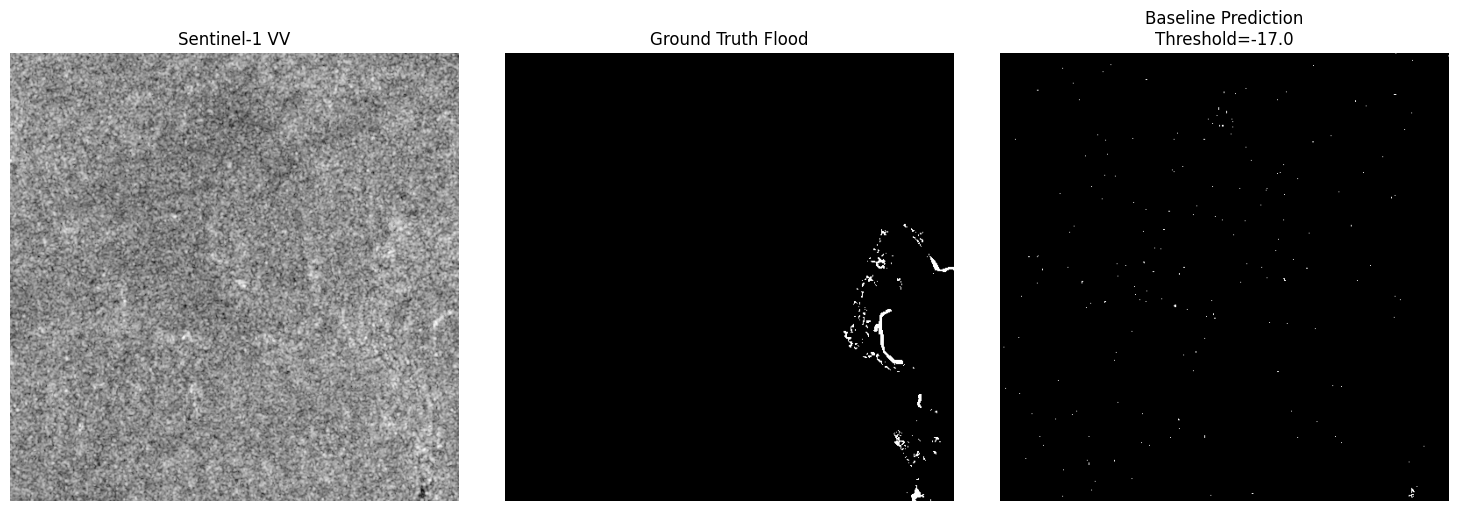

Baseline visualization saved successfully.
Path: /content/sen1floods11/f02_results/F02_baseline_visualization.png
Image shape: (512, 512)


In [45]:
# ============================================================
# F-02 — Cell 23 FIX
# Save baseline visualization correctly
# ============================================================

# Use the 2-D prediction created in the visualization fix
# instead of the flattened prediction used for metrics.

figure_path = os.path.join(
    RESULTS_DIR,
    "F02_baseline_visualization.png"
)

# Safety check
if prediction_2d.shape != label.shape:
    raise ValueError(
        f"Shape mismatch: prediction={prediction_2d.shape}, "
        f"label={label.shape}"
    )

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

# 1. Sentinel-1 VV
axes[0].imshow(
    vv,
    cmap="gray"
)
axes[0].set_title("Sentinel-1 VV")
axes[0].axis("off")

# 2. Ground truth
axes[1].imshow(
    label,
    cmap="gray"
)
axes[1].set_title("Ground Truth Flood")
axes[1].axis("off")

# 3. Baseline prediction
axes[2].imshow(
    prediction_2d,
    cmap="gray"
)
axes[2].set_title(
    f"Baseline Prediction\nThreshold={BEST_THRESHOLD:.1f}"
)
axes[2].axis("off")

plt.tight_layout()

# Save figure
plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Baseline visualization saved successfully.")
print("Path:", figure_path)
print("Image shape:", prediction_2d.shape)

In [46]:
# ============================================================
# F-02 — Cell 24: Generate experiment summary
# ============================================================

summary_path = os.path.join(
    RESULTS_DIR,
    "F02_summary.txt"
)

summary = f"""
F-02 — FLOOD BASELINE EXPERIMENT
================================

Dataset:
Sen1Floods11

Split sizes:
Training   : {len(train_pairs)}
Validation : {len(valid_pairs)}
Test       : {len(test_pairs)}

Baseline:
Sentinel-1 VV thresholding

Threshold selection:
Validation set

Selected threshold:
{BEST_THRESHOLD:.4f}

FINAL TEST RESULTS
------------------
Precision : {test_metrics['precision']:.6f}
Recall    : {test_metrics['recall']:.6f}
F1-score  : {test_metrics['f1']:.6f}
IoU       : {test_metrics['iou']:.6f}

Confusion counts:
TN : {test_metrics['TN']}
FP : {test_metrics['FP']}
FN : {test_metrics['FN']}
TP : {test_metrics['TP']}

False-alarm rate:
{false_alarm_rate:.6f}

Missed-flood rate:
{missed_flood_rate:.6f}

Interpretation:
This experiment establishes a simple Sentinel-1 VV
threshold baseline. It is not treated as the final
research solution. Its purpose is to provide a
reproducible reference for subsequent experiments.
"""

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary)

print(summary)
print("\nSaved:", summary_path)


F-02 — FLOOD BASELINE EXPERIMENT

Dataset:
Sen1Floods11

Split sizes:
Training   : 251
Validation : 88
Test       : 89

Baseline:
Sentinel-1 VV thresholding

Threshold selection:
Validation set

Selected threshold:
-17.0000

FINAL TEST RESULTS
------------------
Precision : 0.692166
Recall    : 0.530743
F1-score  : 0.600801
IoU       : 0.429389

Confusion counts:
TN : 19679821
FP : 590124
FN : 1173178
TP : 1326897

False-alarm rate:
0.029113

Missed-flood rate:
0.469257

Interpretation:
This experiment establishes a simple Sentinel-1 VV
threshold baseline. It is not treated as the final
research solution. Its purpose is to provide a
reproducible reference for subsequent experiments.


Saved: /content/sen1floods11/f02_results/F02_summary.txt


In [47]:
# ============================================================
# F-02 — Cell 24: Generate experiment summary
# ============================================================

summary_path = os.path.join(
    RESULTS_DIR,
    "F02_summary.txt"
)

summary = f"""
F-02 — FLOOD BASELINE EXPERIMENT
================================

Dataset:
Sen1Floods11

Split sizes:
Training   : {len(train_pairs)}
Validation : {len(valid_pairs)}
Test       : {len(test_pairs)}

Baseline:
Sentinel-1 VV thresholding

Threshold selection:
Validation set

Selected threshold:
{BEST_THRESHOLD:.4f}

FINAL TEST RESULTS
------------------
Precision : {test_metrics['precision']:.6f}
Recall    : {test_metrics['recall']:.6f}
F1-score  : {test_metrics['f1']:.6f}
IoU       : {test_metrics['iou']:.6f}

Confusion counts:
TN : {test_metrics['TN']}
FP : {test_metrics['FP']}
FN : {test_metrics['FN']}
TP : {test_metrics['TP']}

False-alarm rate:
{false_alarm_rate:.6f}

Missed-flood rate:
{missed_flood_rate:.6f}

Interpretation:
This experiment establishes a simple Sentinel-1 VV
threshold baseline. It is not treated as the final
research solution. Its purpose is to provide a
reproducible reference for subsequent experiments.
"""

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary)

print(summary)
print("\nSaved:", summary_path)


F-02 — FLOOD BASELINE EXPERIMENT

Dataset:
Sen1Floods11

Split sizes:
Training   : 251
Validation : 88
Test       : 89

Baseline:
Sentinel-1 VV thresholding

Threshold selection:
Validation set

Selected threshold:
-17.0000

FINAL TEST RESULTS
------------------
Precision : 0.692166
Recall    : 0.530743
F1-score  : 0.600801
IoU       : 0.429389

Confusion counts:
TN : 19679821
FP : 590124
FN : 1173178
TP : 1326897

False-alarm rate:
0.029113

Missed-flood rate:
0.469257

Interpretation:
This experiment establishes a simple Sentinel-1 VV
threshold baseline. It is not treated as the final
research solution. Its purpose is to provide a
reproducible reference for subsequent experiments.


Saved: /content/sen1floods11/f02_results/F02_summary.txt


In [49]:
# F-02 Cell 25 — Corrected Final Verification

print("=" * 60)
print("F-02 FINAL OUTPUT VERIFICATION")
print("=" * 60)

expected_outputs = [
    "F02_baseline_visualization.png",
    "F02_per_sample_results.csv",
    "F02_summary.txt",
    "F02_test_metrics.csv",
    "F02_validation_thresholds.csv"
]

all_found = True

for filename in expected_outputs:
    path = os.path.join(RESULTS_DIR, filename)

    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"✓ {filename} — {size_kb:.2f} KB")
    else:
        print(f"✗ MISSING: {filename}")
        all_found = False

print("\n" + "-" * 60)

if all_found:
    print("SUCCESS: All F-02 output files are present.")
    print("F-02 baseline experiment is complete.")
else:
    print("WARNING: One or more F-02 output files are missing.")

print("\nResults directory:")
print(RESULTS_DIR)

print("=" * 60)

F-02 FINAL OUTPUT VERIFICATION
✓ F02_baseline_visualization.png — 913.88 KB
✓ F02_per_sample_results.csv — 11.16 KB
✓ F02_summary.txt — 0.71 KB
✓ F02_test_metrics.csv — 0.23 KB
✓ F02_validation_thresholds.csv — 2.38 KB

------------------------------------------------------------
SUCCESS: All F-02 output files are present.
F-02 baseline experiment is complete.

Results directory:
/content/sen1floods11/f02_results


In [50]:
# F-02 Final Conclusion

print("=" * 70)
print("F-02 — VV THRESHOLD BASELINE: CONCLUSION")
print("=" * 70)

print("""
Objective:
Establish a simple Sentinel-1 VV backscatter threshold as a baseline
for flood inundation detection on the Sen1Floods11 dataset.

Method:
A threshold was selected using the validation split. Pixels with VV
backscatter below the selected threshold were classified as flooded.
The selected threshold was then evaluated on the independent test split.

Evaluation:
The baseline was evaluated using:
- Precision
- Recall
- F1-score
- Intersection over Union (IoU)
- False-alarm rate
- Missed-flood rate

Key interpretation:
This experiment establishes a reproducible single-polarization baseline.
It provides a reference against which more informative approaches can be
compared.

Important limitation:
A single VV threshold assumes that low backscatter is sufficient to
identify flooding. However, backscatter can vary because of land cover,
surface conditions, vegetation, geometry and other environmental factors.
Therefore, this baseline is not expected to represent the full capability
of Sentinel-1 flood detection.

Research significance:
The F-02 baseline gives us a measurable reference point. The next
experiment will investigate whether additional Sentinel-1 information,
particularly VH polarization, can improve flood detection compared with
the single-VV baseline.

Conclusion:
F-02 successfully established the baseline experiment and generated
reproducible validation and test results. No claim of improvement is
made at this stage.

Next experiment:
F-03 — VV + VH baseline comparison.
""")

print("=" * 70)
print("F-02 COMPLETE")
print("=" * 70)

F-02 — VV THRESHOLD BASELINE: CONCLUSION

Objective:
Establish a simple Sentinel-1 VV backscatter threshold as a baseline
for flood inundation detection on the Sen1Floods11 dataset.

Method:
A threshold was selected using the validation split. Pixels with VV
backscatter below the selected threshold were classified as flooded.
The selected threshold was then evaluated on the independent test split.

Evaluation:
The baseline was evaluated using:
- Precision
- Recall
- F1-score
- Intersection over Union (IoU)
- False-alarm rate
- Missed-flood rate

Key interpretation:
This experiment establishes a reproducible single-polarization baseline.
It provides a reference against which more informative approaches can be
compared.

Important limitation:
A single VV threshold assumes that low backscatter is sufficient to
identify flooding. However, backscatter can vary because of land cover,
surface conditions, vegetation, geometry and other environmental factors.
Therefore, this baseline is not exp